In [11]:
# Linalg support
import numpy as np

# Plotting support
import matplotlib.pyplot as plt

# Helper handling
import glob
from dataclasses import dataclass

In [12]:
@dataclass
class Measurement:
    coupling_strength: float
    state_size: int
    prediction_length: int

    train_losses: list
    test_losses: list
    train_predictions: np.ndarray
    train_targets: np.ndarray
    test_predictions: np.ndarray
    test_targets: np.ndarray
    test_pearson: float
    train_pearson: float

In [16]:
# coupling stength, state size, prediction length

prediction_lengths =  [1, 10, 20, 50, 100, 500]

results = {}

for length in prediction_lengths:
    results[length] = []
    files = glob.glob(f"fit_results/*_{length}.npy")

    for file in files:
        data = np.load(file, allow_pickle=True).item()
        results[length].append(
            [data.coupling_strength, data.state_size, data.test_pearson]
        )

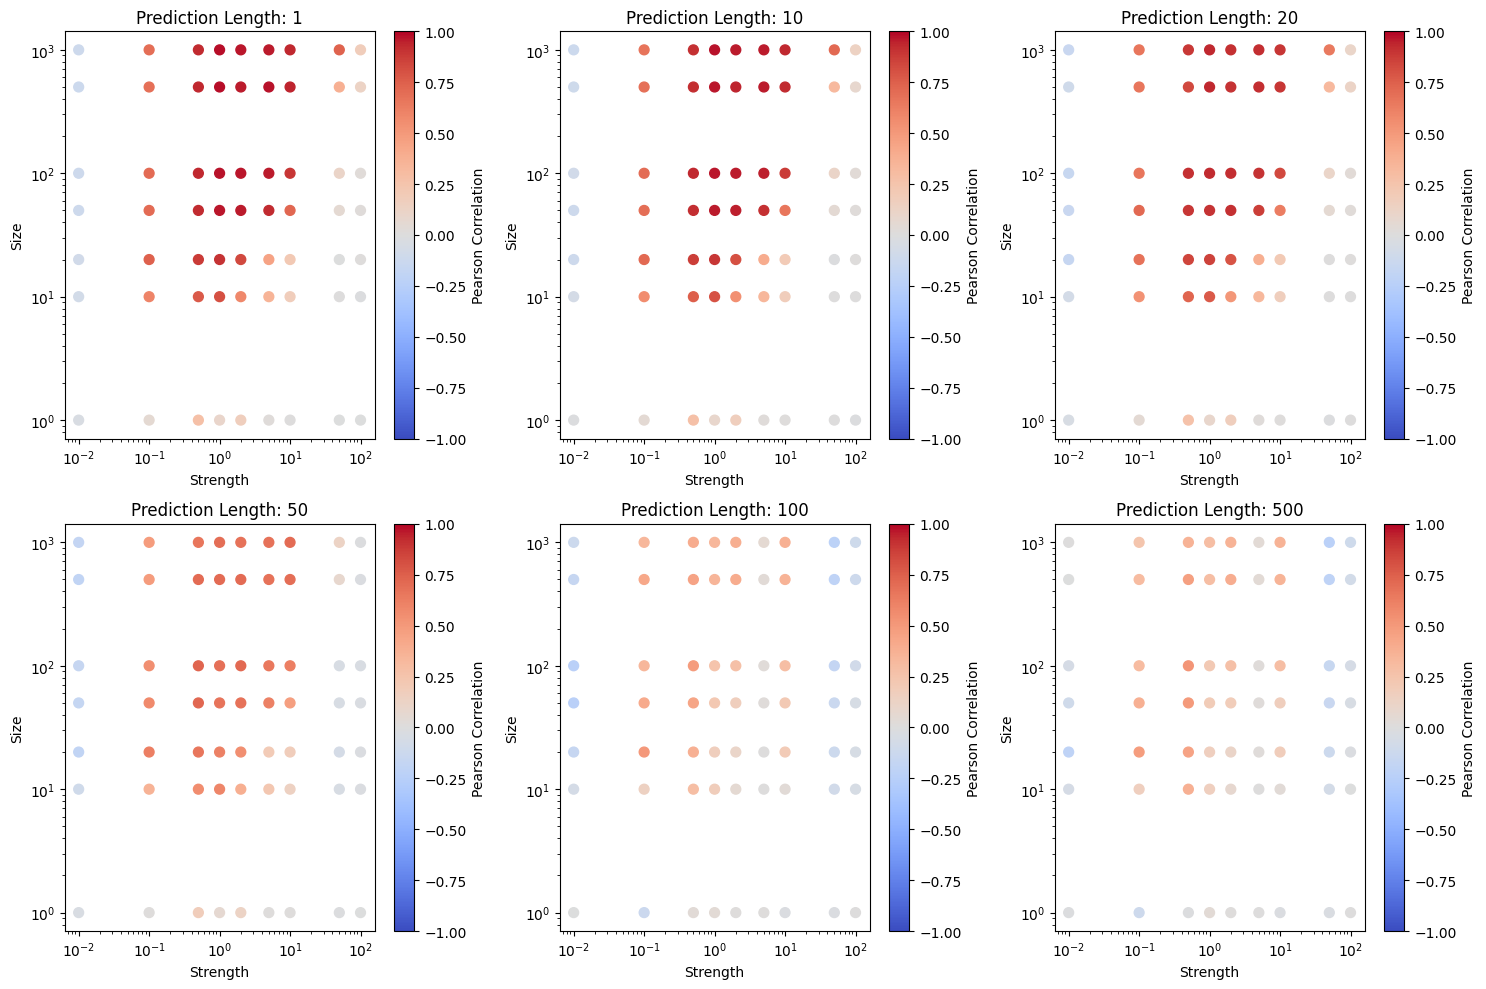

In [25]:
# Define the color range across all datasets
# For simplicity, assuming the Pearson correlation values range from -1 to 1
# If your actual data varies, adjust these limits accordingly
norm = plt.Normalize(-1, 1)
cmap = plt.get_cmap('coolwarm')


# Generate a figure and a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes_flat = axes.flatten()

for i, length in enumerate(prediction_lengths):
    # For simplicity, using the same data for each prediction length
    # You should replace this with your actual data for each prediction length
    data_points = results[length]
    strength, size, pearson = zip(*data_points)

    # Convert Pearson correlation values to a colormap
    # norm = plt.Normalize(min(pearson), max(pearson))
    # cmap = plt.get_cmap('coolwarm')
    
    scatter = axes_flat[i].scatter(strength, size, c=pearson, cmap='coolwarm', s=50, norm=norm)
    
    # Adding a colorbar to each subplot
    fig.colorbar(scatter, ax=axes_flat[i], label='Pearson Correlation')
    
    # Set title for each subplot
    axes_flat[i].set_title(f'Prediction Length: {length}')
    axes_flat[i].set_xlabel('Strength')
    axes_flat[i].set_ylabel('Size')

    # Set axis scaling
    axes_flat[i].set_xscale('log')
    axes_flat[i].set_yscale('log')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

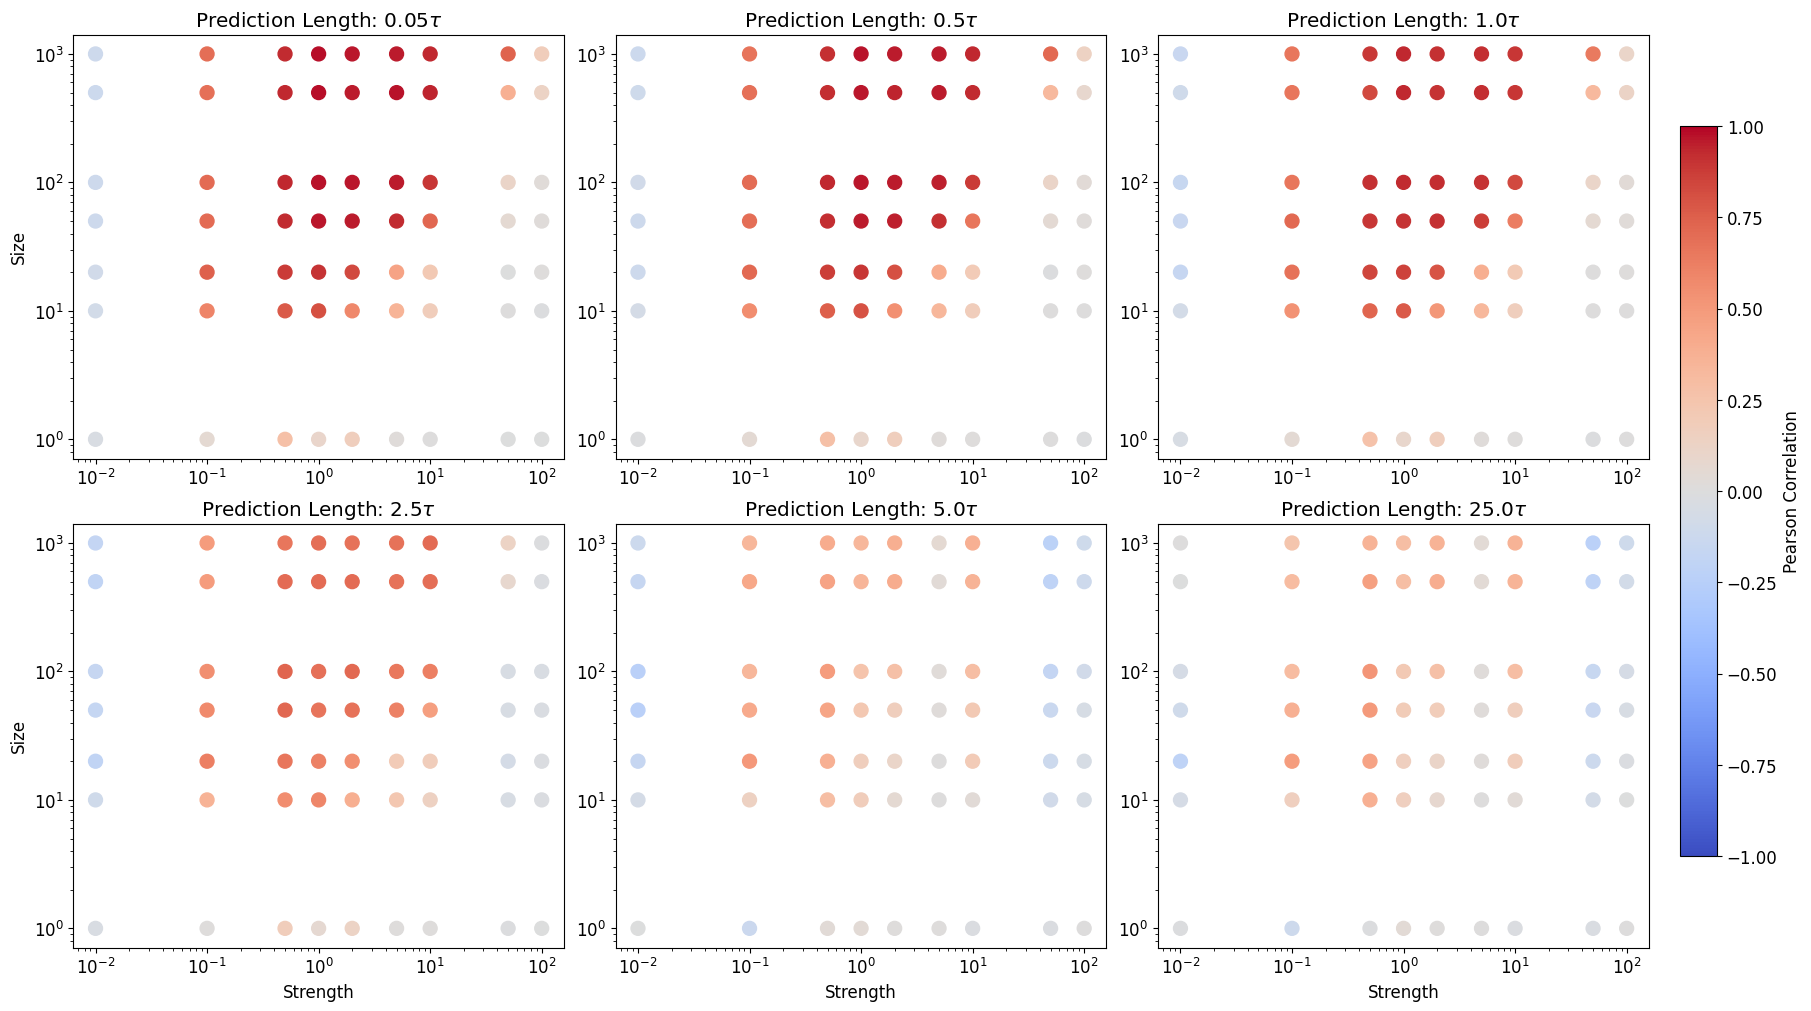

In [41]:
# Normalize color range for Pearson correlation values across all datasets
norm = plt.Normalize(-1, 1)  # Assuming Pearson values range from -1 to 1
cmap = plt.get_cmap('coolwarm')

plt.rcParams.update({'font.size': 12})

# Create a figure and a 2x3 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), constrained_layout=True)

for i, ax in enumerate(axes.flat):
    # Using the same example data for each subplot for demonstration purposes
    # Replace with actual data for each prediction length
    data_points = results[prediction_lengths[i]]
    strength, size, pearson = zip(*data_points)
    scatter = ax.scatter(strength, size, c=pearson, cmap=cmap, norm=norm, s=100)
    
    # Set title for each subplot
    ax.set_title(rf'Prediction Length: {prediction_lengths[i] / 20}$\tau$')
    
    # Only show x and y labels for the outer plots
    if i >= 3:  # Bottom row
        ax.set_xlabel('Strength')
    if i % 3 == 0:  # First column
        ax.set_ylabel('Size')

    # Set axis scaling
    ax.set_xscale('log')
    ax.set_yscale('log')

# Creating a single shared colorbar for all subplots
cbar = fig.colorbar(
    scatter, ax=axes.ravel().tolist(), shrink=0.8, label='Pearson Correlation', pad=0.02
    )

plt.savefig('sine-scan.pdf')
plt.show()